In [1]:
import pandas as pd

# Load dataset
file_path = "cleaned_dataset_no_outliers.csv"  # Ensure the file is in the same directory
df = pd.read_csv(file_path)

# Display first 5 rows to check the data
df.head()


C:\Users\mihir\AppData\Local\Temp\ipykernel_33456\795586509.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000254,254 Augusta,False,False,11.7,12.467000,0.170000,0.137000,JPL 32,2459000.5,...,0.000004,0.000040,0.000044,0.000021,6.240000e-09,1.150000e-09,0.000068,0.000005,MBA,0.40909
1,2000473,473 Nolli (1901 GC),False,False,11.7,12.394000,0.138000,0.138000,JPL 34,2459000.5,...,0.000005,0.000019,0.000029,0.000021,1.320000e-08,1.520000e-09,0.000092,0.000011,MBA,0.37280
2,2000719,719 Albert (1911 MT),True,False,15.4,7.581494,0.145937,-0.167142,JPL 214,2459000.5,...,0.000003,0.000017,0.000017,0.000003,3.910000e-09,3.310000e-10,0.000010,0.000002,AMO,0.39148
3,2000724,724 Hapag (1911 NC),False,False,13.8,9.492000,0.103000,0.198000,JPL 29,2459000.5,...,0.000005,0.000019,0.000021,0.000007,1.240000e-08,1.550000e-09,0.000026,0.000009,MBA,0.48206
4,2000728,728 Leonisis (1912 NU),False,False,12.9,5.887000,0.160000,0.481000,JPL 41,2459000.5,...,0.000003,0.000048,0.000052,0.000020,6.060000e-09,1.080000e-09,0.000069,0.000005,MBA,0.43402


In [2]:
# Check data types and column names
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368696 entries, 0 to 368695
Data columns (total 40 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   asteroid_id                           368696 non-null  int64  
 1   asteroid_name                         368696 non-null  object 
 2   near_earth_object                     368696 non-null  bool   
 3   potentially_hazardous                 368696 non-null  object 
 4   absolute_magnitude                    368696 non-null  float64
 5   diameter_km                           368696 non-null  float64
 6   surface_reflectivity                  368696 non-null  float64
 7   diameter_uncertainty_km               368696 non-null  float64
 8   orbit_solution_id                     368696 non-null  object 
 9   orbit_epoch                           368696 non-null  float64
 10  orbit_epoch_mjd                       368696 non-null  int64  
 11  

In [3]:
# Check unique values in the column
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

# Check data types
print(df[["potentially_hazardous", "near_earth_object"]].dtypes)


Unique values in 'potentially_hazardous': [False True 'False' 'True' 'FALSE' 'N' 'TRUE']
Unique values in 'near_earth_object': [False  True]
potentially_hazardous    object
near_earth_object          bool
dtype: object


In [4]:
# Convert all values to consistent binary format (0 = Non-Hazardous, 1 = Hazardous)
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()  # Convert all to uppercase for consistency

# Define mapping
hazardous_mapping = {
    "TRUE": 1, "FALSE": 0,
    "N": 0  # Assuming 'N' means non-hazardous
}

# Apply mapping
df["potentially_hazardous"] = df["potentially_hazardous"].map(hazardous_mapping).astype(int)


In [5]:
# Convert boolean values to integer (0/1)
df["near_earth_object"] = df["near_earth_object"].astype(int)


In [6]:
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())


Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]


In [7]:
# Categorize 'semi_major_axis_au' into 3 groups: Small, Medium, Large
df["Orbit_Category"] = pd.qcut(df["semi_major_axis_au"], q=3, labels=[0,1,2])

# Categorize 'diameter_km' into 3 groups: Small, Medium, Large
df["Size_Category"] = pd.qcut(df["diameter_km"], q=3, labels=[0,1,2])

# Verify the categories
df[["semi_major_axis_au", "Orbit_Category", "diameter_km", "Size_Category"]].head()


,semi_major_axis_au,Orbit_Category,diameter_km,Size_Category
0,2.194870,0,12.467000,2
1,2.663625,0,12.394000,2
2,2.638602,0,7.581494,2
3,2.454535,0,9.492000,2
4,2.253746,0,5.887000,2


In [8]:
df.to_csv("cleaned_dataset_ARM.csv", index=False)

In [9]:
# Apply One-Hot Encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=["asteroid_class", "Orbit_Category", "Size_Category"], dtype=int)


In [10]:
# Drop unnecessary continuous variables (ARM works best with categorical data)
drop_cols = ["asteroid_id", "asteroid_name", "orbit_solution_id", "orbit_epoch", "orbit_epoch_mjd",
             "orbit_epoch_calendar", "absolute_magnitude", "diameter_km", "surface_reflectivity",
             "diameter_uncertainty_km", "orbital_eccentricity", "semi_major_axis_au",
             "perihelion_distance_au", "orbital_inclination_deg", "longitude_ascending_node_deg",
             "argument_perihelion_deg", "mean_anomaly_deg", "aphelion_distance_au",
             "mean_motion_deg_day", "time_perihelion_passage", "time_perihelion_calendar",
             "orbital_period_days", "orbital_period_years", "earth_moid_au", "earth_moid_ld",
             "uncertainty_eccentricity", "uncertainty_semi_major_axis", "uncertainty_perihelion_distance",
             "uncertainty_orbital_inclination", "uncertainty_longitude_ascending_node",
             "uncertainty_argument_perihelion", "uncertainty_mean_anomaly", "uncertainty_aphelion_distance",
             "uncertainty_mean_motion", "uncertainty_time_perihelion_passage", "uncertainty_orbital_period",
             "orbit_fit_rms"]

df_encoded = df_encoded.drop(columns=drop_cols, errors='ignore')

In [11]:
df_encoded.head()

,near_earth_object,potentially_hazardous,asteroid_class_AMO,asteroid_class_APO,asteroid_class_IMB,asteroid_class_MBA,asteroid_class_MCA,asteroid_class_OMB,Orbit_Category_0,Orbit_Category_1,Orbit_Category_2,Size_Category_0,Size_Category_1,Size_Category_2
0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
1,0,0,0,0,0,1,0,0,1,0,0,0,0,1
2,1,0,1,0,0,0,0,0,1,0,0,0,0,1
3,0,0,0,0,0,1,0,0,1,0,0,0,0,1
4,0,0,0,0,0,1,0,0,1,0,0,0,0,1


In [12]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply Apriori Algorithm
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

# Generate Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Display top 15 rules sorted by lift
rules.sort_values(by="lift", ascending=False).head(15)


c:\Python310\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
59,(asteroid_class_OMB),"(Size_Category_2, Orbit_Category_2)",0.056030,0.148700,0.030337,0.541437,3.641141,0.022005,1.856451,0.768415
58,"(Size_Category_2, Orbit_Category_2)",(asteroid_class_OMB),0.148700,0.056030,0.030337,0.204013,3.641141,0.022005,1.185911,0.852062
61,(Orbit_Category_2),"(asteroid_class_OMB, Size_Category_2)",0.333334,0.030337,0.030337,0.091010,2.999992,0.020224,1.066748,1.000000
55,(Orbit_Category_2),"(asteroid_class_OMB, Size_Category_1)",0.333334,0.016032,0.016032,0.048096,2.999992,0.010688,1.033684,1.000000
52,"(asteroid_class_OMB, Size_Category_1)",(Orbit_Category_2),0.016032,0.333334,0.016032,1.000000,2.999992,0.010688,inf,0.677528
8,(asteroid_class_OMB),(Orbit_Category_2),0.056030,0.333334,0.056030,1.000000,2.999992,0.037353,inf,0.706236
56,"(asteroid_class_OMB, Size_Category_2)",(Orbit_Category_2),0.030337,0.333334,0.030337,1.000000,2.999992,0.020224,inf,0.687523
9,(Orbit_Category_2),(asteroid_class_OMB),0.333334,0.056030,0.056030,0.168089,2.999992,0.037353,1.134701,1.000000
54,(asteroid_class_OMB),"(Size_Category_1, Orbit_Category_2)",0.056030,0.104278,0.016032,0.286136,2.743966,0.010189,1.254751,0.673288
53,"(Size_Category_1, Orbit_Category_2)",(asteroid_class_OMB),0.104278,0.056030,0.016032,0.153744,2.743966,0.010189,1.115467,0.709555


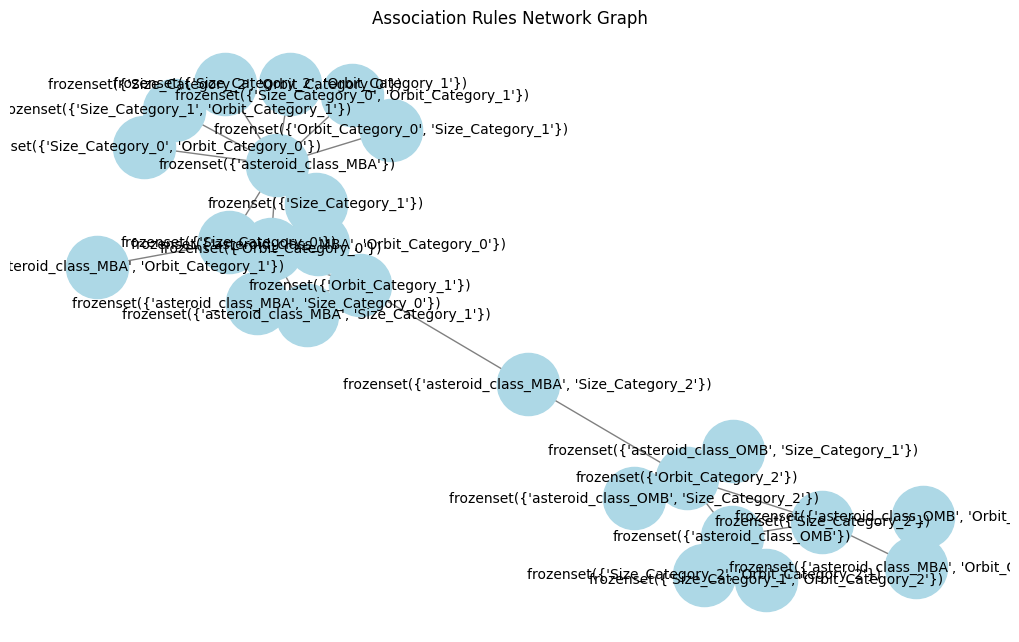

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.Graph()

# Add edges
for i, row in rules.iterrows():
    G.add_edge(row["antecedents"], row["consequents"], weight=row["lift"])

# Plot the network graph
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2000, font_size=10)
plt.title("Association Rules Network Graph")
plt.show()


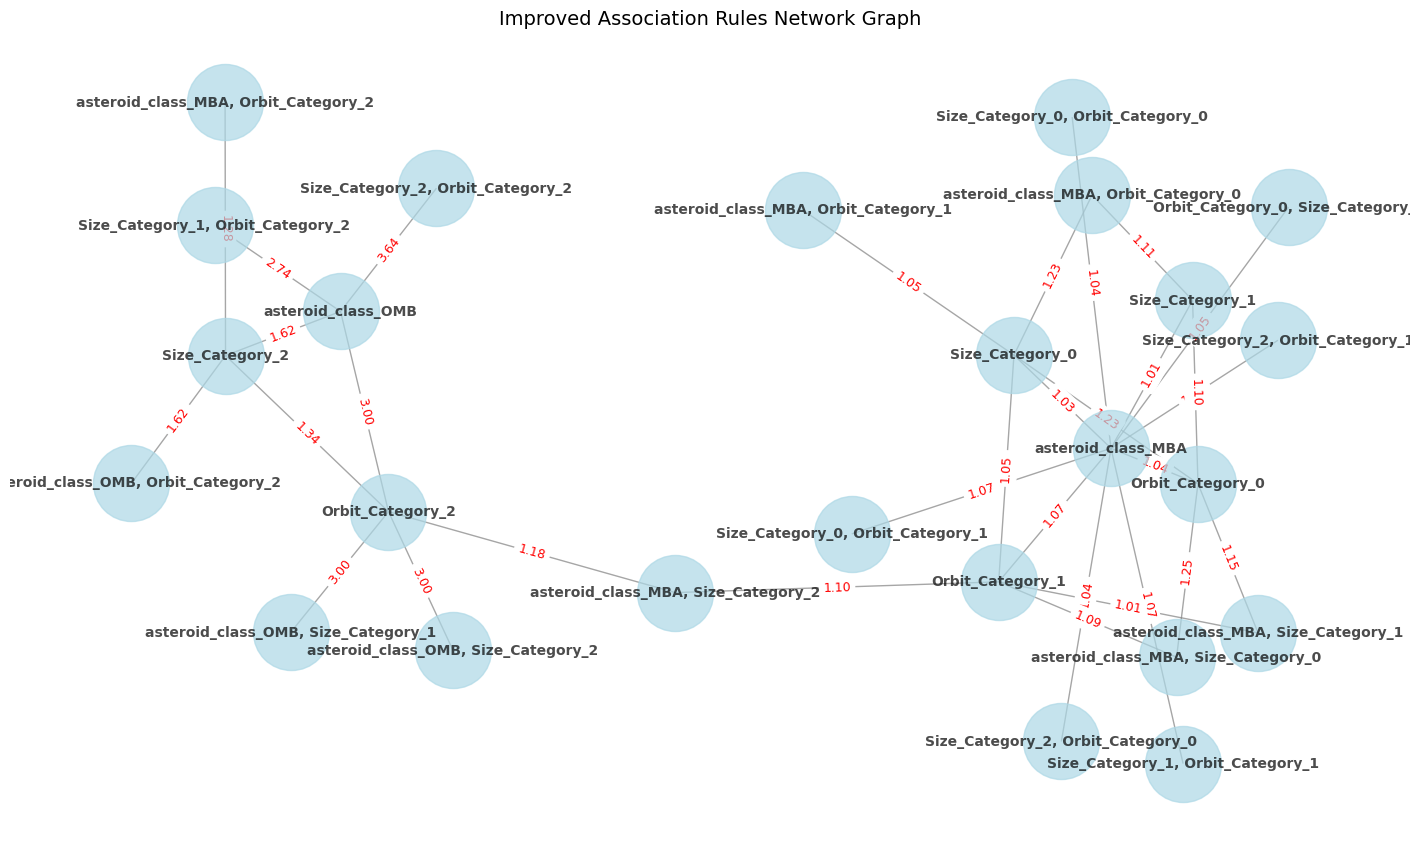

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.Graph()

# Add edges from association rules
for i, row in rules.iterrows():
    antecedents = ', '.join(row["antecedents"])  # Convert frozenset to string
    consequents = ', '.join(row["consequents"])  # Convert frozenset to string
    G.add_edge(antecedents, consequents, weight=row["lift"])  # Use lift as weight

# Set figure size
plt.figure(figsize=(14, 8))

# Define layout
pos = nx.spring_layout(G, k=0.5)  # k controls the spacing

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
        node_size=3000, font_size=10, font_weight='bold', alpha=0.7)

# Add edge labels (lift values)
edge_labels = {(list(edge)[0], list(edge)[1]): f"{G.edges[edge]['weight']:.2f}" for edge in G.edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='red')

# Show plot
plt.title("Improved Association Rules Network Graph", fontsize=14)
plt.show()


# Analyze hazardous asteroids specifically

In [16]:
# Lower min_support to include rare hazardous asteroid rules
frequent_itemsets = apriori(df_encoded, min_support=0.0005, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Filter for hazardous asteroids
hazardous_rules = rules[
    rules['antecedents'].astype(str).str.contains("potentially_hazardous") |
    rules['consequents'].astype(str).str.contains("potentially_hazardous")
]

# Display top 10 hazardous rules
hazardous_rules_sorted = hazardous_rules.sort_values(by="lift", ascending=False).head(10)
hazardous_rules_sorted


c:\Python310\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
10,(asteroid_class_APO),(potentially_hazardous),0.001679,0.000553,0.000523,0.311793,563.514270,0.000523,1.452248,0.999904
11,(potentially_hazardous),(asteroid_class_APO),0.000553,0.001679,0.000523,0.946078,563.514270,0.000523,18.514319,0.998778
44,"(near_earth_object, asteroid_class_APO)",(potentially_hazardous),0.001679,0.000553,0.000523,0.311793,563.514270,0.000523,1.452248,0.999904
45,"(near_earth_object, potentially_hazardous)",(asteroid_class_APO),0.000553,0.001679,0.000523,0.946078,563.514270,0.000523,18.514319,0.998778
48,(asteroid_class_APO),"(near_earth_object, potentially_hazardous)",0.001679,0.000553,0.000523,0.311793,563.514270,0.000523,1.452248,0.999904
49,(potentially_hazardous),"(near_earth_object, asteroid_class_APO)",0.000553,0.001679,0.000523,0.946078,563.514270,0.000523,18.514319,0.998778
0,(near_earth_object),(potentially_hazardous),0.002617,0.000553,0.000553,0.211399,382.068394,0.000552,1.267367,1.000000
1,(potentially_hazardous),(near_earth_object),0.000553,0.002617,0.000553,1.000000,382.068394,0.000552,inf,0.997935
46,"(asteroid_class_APO, potentially_hazardous)",(near_earth_object),0.000523,0.002617,0.000523,1.000000,382.068394,0.000522,inf,0.997905
47,(near_earth_object),"(asteroid_class_APO, potentially_hazardous)",0.002617,0.000523,0.000523,0.200000,382.068394,0.000522,1.249346,1.000000


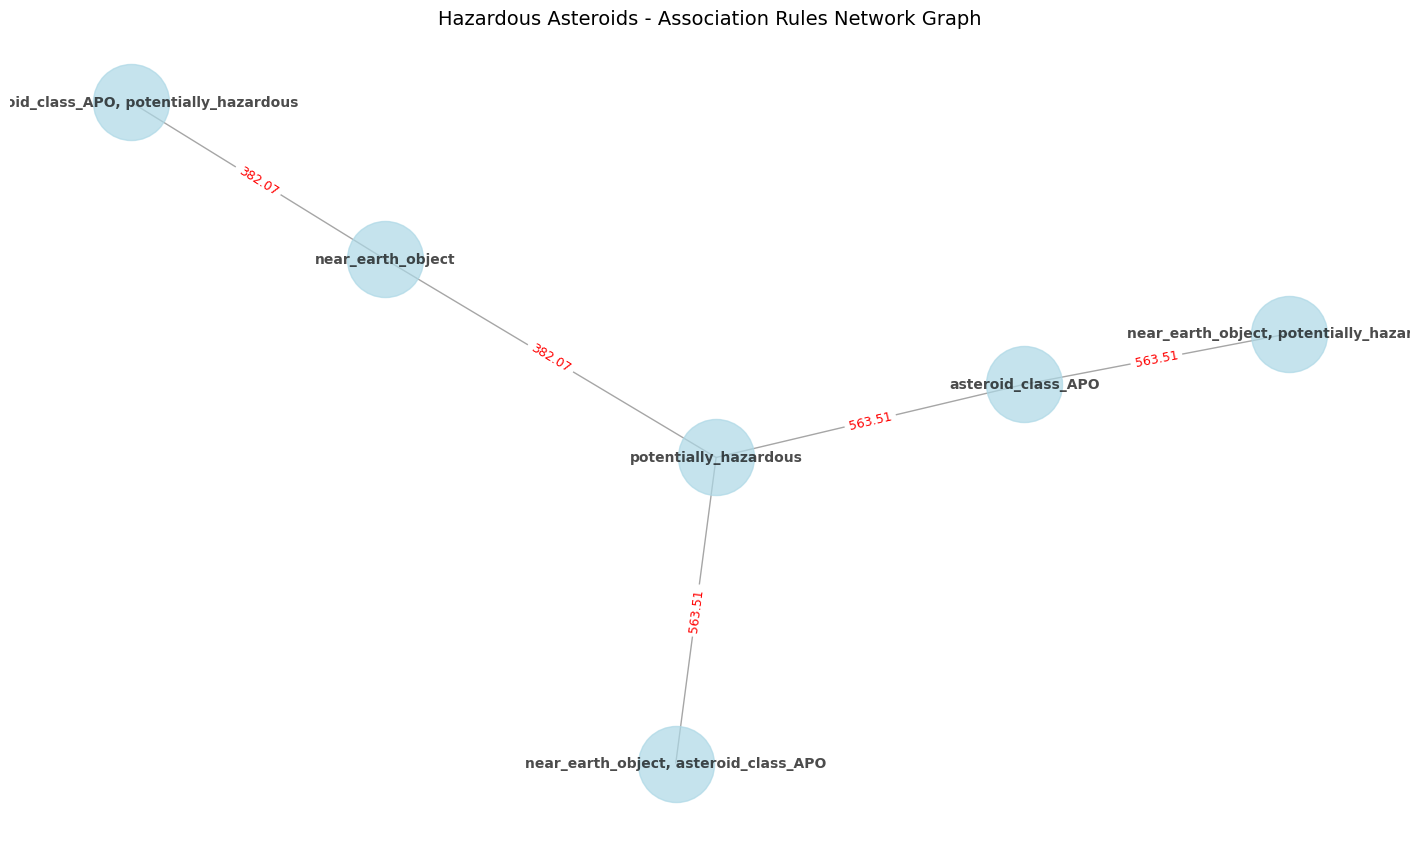

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph for hazardous asteroid rules
G_hazardous = nx.Graph()

# Add edges from association rules (only for hazardous asteroids)
for i, row in hazardous_rules_sorted.iterrows():
    antecedents = ', '.join(row["antecedents"])  # Convert frozenset to string
    consequents = ', '.join(row["consequents"])  # Convert frozenset to string
    G_hazardous.add_edge(antecedents, consequents, weight=row["lift"])  # Use lift as weight

# Set figure size
plt.figure(figsize=(14, 8))

# Define layout for better readability
pos = nx.spring_layout(G_hazardous, k=0.6)  # k controls the spacing

# Draw nodes and edges
nx.draw(G_hazardous, pos, with_labels=True, node_color='lightblue', edge_color='gray',
        node_size=3000, font_size=10, font_weight='bold', alpha=0.7)

# Add edge labels (lift values)
edge_labels = {(list(edge)[0], list(edge)[1]): f"{G_hazardous.edges[edge]['weight']:.2f}" for edge in G_hazardous.edges}
nx.draw_networkx_edge_labels(G_hazardous, pos, edge_labels=edge_labels, font_size=9, font_color='red')

# Show plot
plt.title("Hazardous Asteroids - Association Rules Network Graph", fontsize=14)
plt.show()


In [18]:
# Select important columns for tabular summary
arm_summary = rules[["antecedents", "consequents", "support", "confidence", "lift"]]

# Convert frozensets to readable strings
arm_summary["antecedents"] = arm_summary["antecedents"].apply(lambda x: ', '.join(list(x)))
arm_summary["consequents"] = arm_summary["consequents"].apply(lambda x: ', '.join(list(x)))

# Sort rules by lift (strongest associations first)
arm_summary_sorted = arm_summary.sort_values(by="lift", ascending=False).head(20)


arm_summary_sorted.head(20)


C:\Users\mihir\AppData\Local\Temp\ipykernel_33456\1048937779.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  arm_summary["antecedents"] = arm_summary["antecedents"].apply(lambda x: ', '.join(list(x)))
C:\Users\mihir\AppData\Local\Temp\ipykernel_33456\1048937779.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  arm_summary["consequents"] = arm_summary["consequents"].apply(lambda x: ', '.join(list(x)))


,antecedents,consequents,support,confidence,lift
45,"near_earth_object, potentially_hazardous",asteroid_class_APO,0.000523,0.946078,563.514270
44,"near_earth_object, asteroid_class_APO",potentially_hazardous,0.000523,0.311793,563.514270
48,asteroid_class_APO,"near_earth_object, potentially_hazardous",0.000523,0.311793,563.514270
49,potentially_hazardous,"near_earth_object, asteroid_class_APO",0.000523,0.946078,563.514270
10,asteroid_class_APO,potentially_hazardous,0.000523,0.311793,563.514270
11,potentially_hazardous,asteroid_class_APO,0.000523,0.946078,563.514270
158,"asteroid_class_APO, Size_Category_0","near_earth_object, Orbit_Category_0",0.000749,0.904918,420.201082
155,"near_earth_object, Orbit_Category_0","asteroid_class_APO, Size_Category_0",0.000749,0.347607,420.201082
62,"near_earth_object, Orbit_Category_0",asteroid_class_APO,0.001505,0.698992,416.342032
67,asteroid_class_APO,"near_earth_object, Orbit_Category_0",0.001505,0.896607,416.342032
